In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    roc_curve,
    auc,
    confusion_matrix
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import seaborn as sns

In [2]:
os.makedirs("figures", exist_ok=True)
print("Setup complete.")

Setup complete.


In [3]:
df = pd.read_csv("Personal_Finance_Dataset.csv")
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns.tolist())
print(df.info())

         Date                   Transaction Description      Category  \
0  2020-01-02                               Score each.  Food & Drink   
1  2020-01-02                       Quality throughout.     Utilities   
2  2020-01-04        Instead ahead despite measure ago.          Rent   
3  2020-01-05  Information last everything thank serve.    Investment   
4  2020-01-13              Future choice whatever from.  Food & Drink   

    Amount     Type  
0  1485.69  Expense  
1  1475.58  Expense  
2  1185.08  Expense  
3  2291.00   Income  
4  1126.88  Expense  
['Date', 'Transaction Description', 'Category', 'Amount', 'Type']
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   str    
 1   Transaction Description  1500 non-null   str    
 2   Category                 1500 non-null   str   

In [4]:
print("Shape:", df.shape)
print(df["Type"].value_counts())
print(df["Category"].value_counts())

Shape: (1500, 5)
Type
Expense    1222
Income      278
Name: count, dtype: int64
Category
Rent                165
Travel              160
Utilities           157
Health & Fitness    152
Shopping            150
Food & Drink        149
Salary              146
Entertainment       143
Investment          142
Other               136
Name: count, dtype: int64


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df_expense = df[df["Type"] == "Expense"].copy()

print(df_expense.head())
print("Expense-only shape:", df_expense.shape)

        Date             Transaction Description      Category   Amount  \
0 2020-01-02                         Score each.  Food & Drink  1485.69   
1 2020-01-02                 Quality throughout.     Utilities  1475.58   
2 2020-01-04  Instead ahead despite measure ago.          Rent  1185.08   
4 2020-01-13        Future choice whatever from.  Food & Drink  1126.88   
5 2020-01-14      Benefit suggest page southern.      Shopping   448.68   

      Type  
0  Expense  
1  Expense  
2  Expense  
4  Expense  
5  Expense  
Expense-only shape: (1222, 5)


In [6]:
df_daily = df_expense.groupby("Date")["Amount"].sum().reset_index()

df_daily["month"] = df_daily["Date"].dt.month
df_daily["weekday"] = df_daily["Date"].dt.weekday

df_daily["lag1"] = df_daily["Amount"].shift(1)
df_daily["lag2"] = df_daily["Amount"].shift(2)
df_daily["lag3"] = df_daily["Amount"].shift(3)
df_daily["lag7"] = df_daily["Amount"].shift(7)

df_daily["rolling3_mean"] = df_daily["Amount"].rolling(3).mean()
df_daily["rolling7_mean"] = df_daily["Amount"].rolling(7).mean()

df_daily["target"] = df_daily["Amount"].shift(-1)

df_daily = df_daily.dropna()

print(df_daily.head())
print(df_daily.columns.tolist())
print(df_daily.shape)

         Date   Amount  month  weekday     lag1     lag2     lag3     lag7  \
7  2020-01-26  1077.09      1        6  1977.47  1914.85  1520.03  2961.27   
8  2020-01-29   166.81      1        2  1077.09  1977.47  1914.85  1185.08   
9  2020-01-30  1158.93      1        3   166.81  1077.09  1977.47  1126.88   
10 2020-01-31  3601.16      1        4  1158.93   166.81  1077.09   448.68   
11 2020-02-02   333.68      2        6  3601.16  1158.93   166.81  1520.03   

    rolling3_mean  rolling7_mean   target  
7     1656.470000    1321.440000   166.81  
8     1073.790000    1175.972857  1158.93  
9      800.943333    1180.551429  3601.16  
10    1642.300000    1630.905714   333.68  
11    1697.923333    1461.427143  1406.62  
['Date', 'Amount', 'month', 'weekday', 'lag1', 'lag2', 'lag3', 'lag7', 'rolling3_mean', 'rolling7_mean', 'target']
(877, 11)


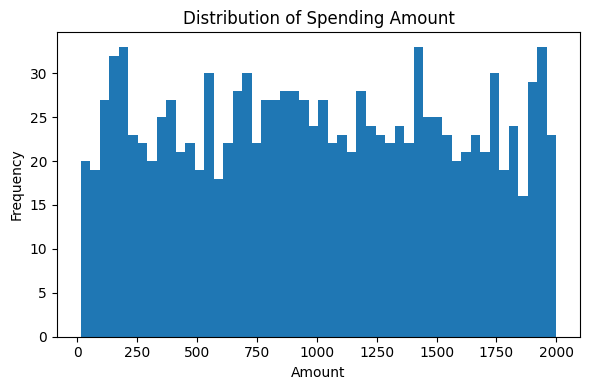

In [7]:
plt.figure(figsize=(6,4))
plt.hist(df_expense["Amount"], bins=50)
plt.title("Distribution of Spending Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

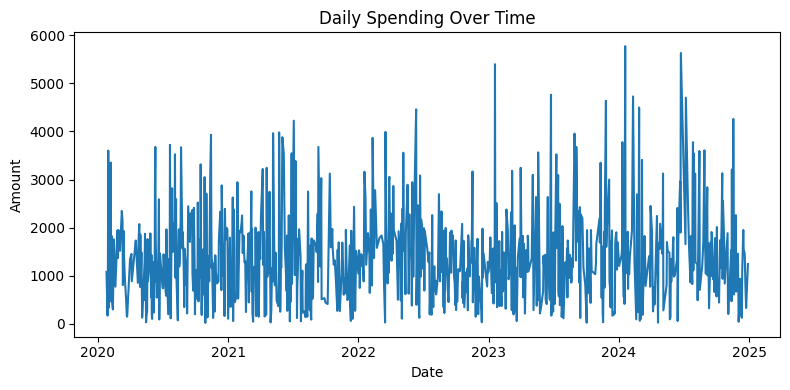

In [8]:
plt.figure(figsize=(8,4))
plt.plot(df_daily["Date"], df_daily["Amount"])
plt.title("Daily Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

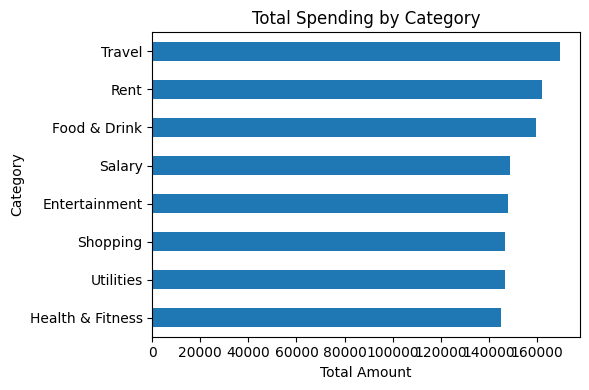

In [9]:
category_sum = df_expense.groupby("Category")["Amount"].sum().sort_values()

plt.figure(figsize=(6,4))
category_sum.plot(kind="barh")
plt.title("Total Spending by Category")
plt.xlabel("Total Amount")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

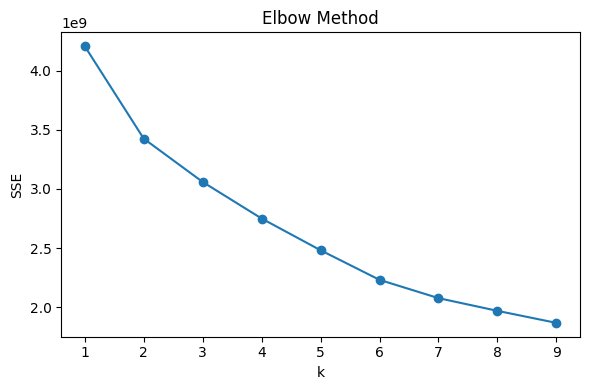

In [10]:
X_cluster = df_daily.drop(columns=["Date", "target"])

sse = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, sse, marker="o")
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("SSE")
plt.tight_layout()
plt.show()

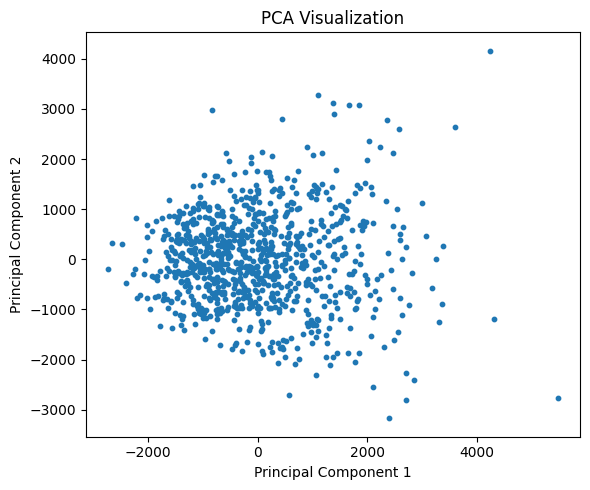

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

In [12]:
X = df_daily.drop(columns=["target", "Date"])
y = df_daily["target"]

split_index = int(len(df_daily) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (701, 9)
X_test: (176, 9)
y_train: (701,)
y_test: (176,)


In [13]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 748.2987545664841
Linear Regression RMSE: 1057.0003195186061


In [14]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 811.1828005681818
Random Forest RMSE: 1083.7750146323392


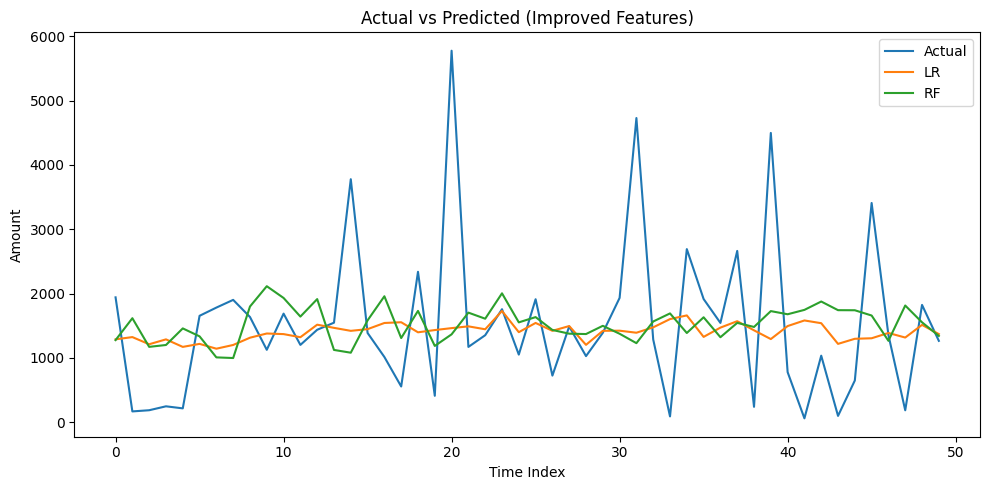

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(lr_pred[:50], label="LR")
plt.plot(rf_pred[:50], label="RF")
plt.legend()
plt.title("Actual vs Predicted (Improved Features)")
plt.xlabel("Time Index")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

In [16]:
y_train_log = np.log1p(y_train)

lr_model_log = LinearRegression()
lr_model_log.fit(X_train, y_train_log)
lr_pred_log = np.expm1(lr_model_log.predict(X_test))

rf_model_log = RandomForestRegressor(random_state=42)
rf_model_log.fit(X_train, y_train_log)
rf_pred_log = np.expm1(rf_model_log.predict(X_test))

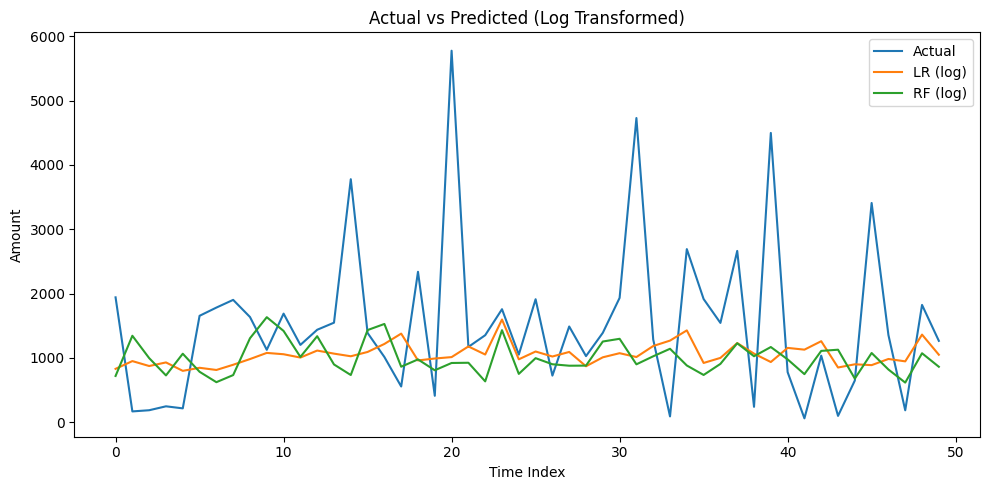

In [17]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(lr_pred_log[:50], label="LR (log)")
plt.plot(rf_pred_log[:50], label="RF (log)")
plt.legend()
plt.title("Actual vs Predicted (Log Transformed)")
plt.xlabel("Time Index")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

In [18]:
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(10))

         Feature  Importance
5           lag3    0.143013
7  rolling3_mean    0.132457
6           lag7    0.131901
8  rolling7_mean    0.130240
0         Amount    0.126996
4           lag2    0.115850
3           lag1    0.110833
1          month    0.061305
2        weekday    0.047405


In [19]:
threshold = df_daily["target"].mean()
y_class = (df_daily["target"] > threshold).astype(int)

y_train_class = y_class.iloc[:split_index]
y_test_class = y_class.iloc[split_index:]

print(y_train_class.value_counts())
print(y_test_class.value_counts())

target
0    385
1    316
Name: count, dtype: int64
target
1    89
0    87
Name: count, dtype: int64


In [20]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train_class)

probs = rf_clf.predict_proba(X_test)[:, 1]
y_pred_class = rf_clf.predict(X_test)

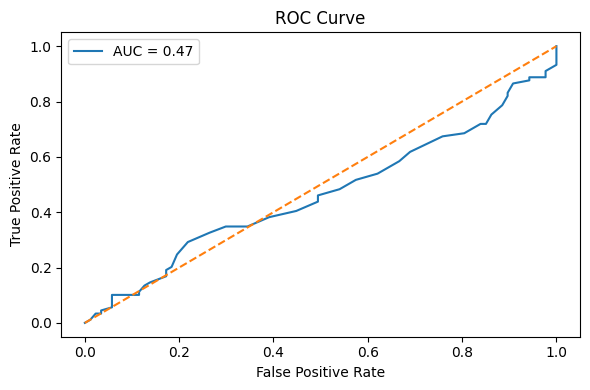

In [21]:
fpr, tpr, _ = roc_curve(y_test_class, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

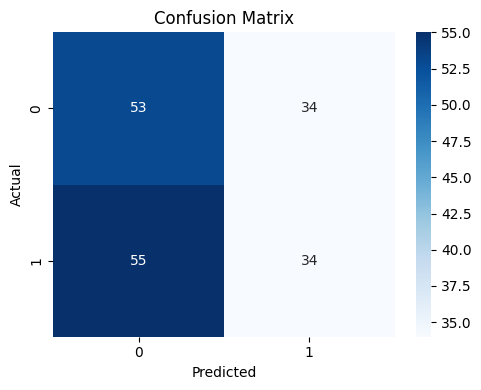

In [22]:
cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [24]:
os.makedirs("figures", exist_ok=True)

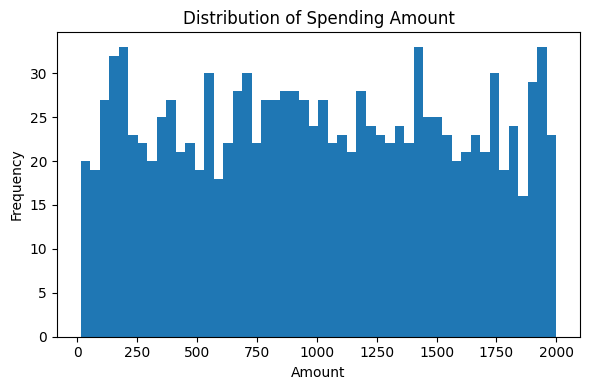

In [25]:
plt.figure(figsize=(6,4))
plt.hist(df_expense["Amount"], bins=50)
plt.title("Distribution of Spending Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/histogram.png", dpi=300, bbox_inches="tight")
plt.show()

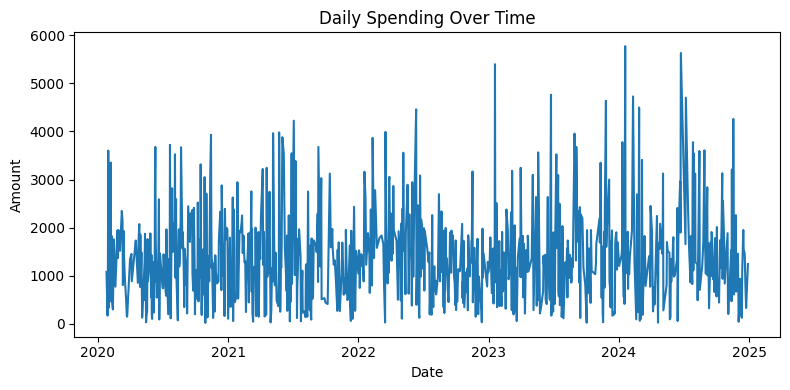

In [26]:
plt.figure(figsize=(8,4))
plt.plot(df_daily["Date"], df_daily["Amount"])
plt.title("Daily Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig("figures/timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

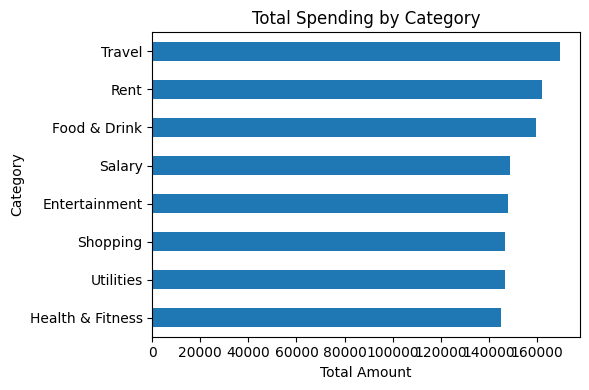

In [27]:
plt.figure(figsize=(6,4))
category_sum.plot(kind="barh")
plt.title("Total Spending by Category")
plt.xlabel("Total Amount")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("figures/category.png", dpi=300, bbox_inches="tight")
plt.show()

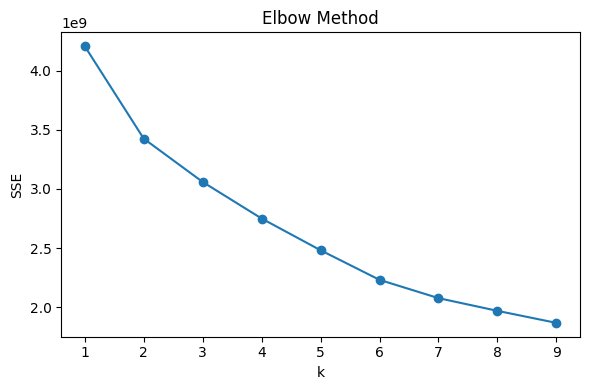

In [28]:
plt.figure(figsize=(6,4))
plt.plot(k_range, sse, marker="o")
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("SSE")
plt.tight_layout()
plt.savefig("figures/elbow.png", dpi=300, bbox_inches="tight")
plt.show()

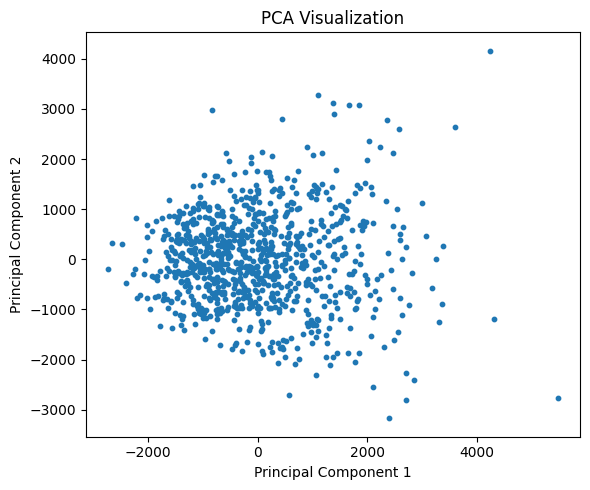

In [29]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig("figures/pca.png", dpi=300, bbox_inches="tight")
plt.show()

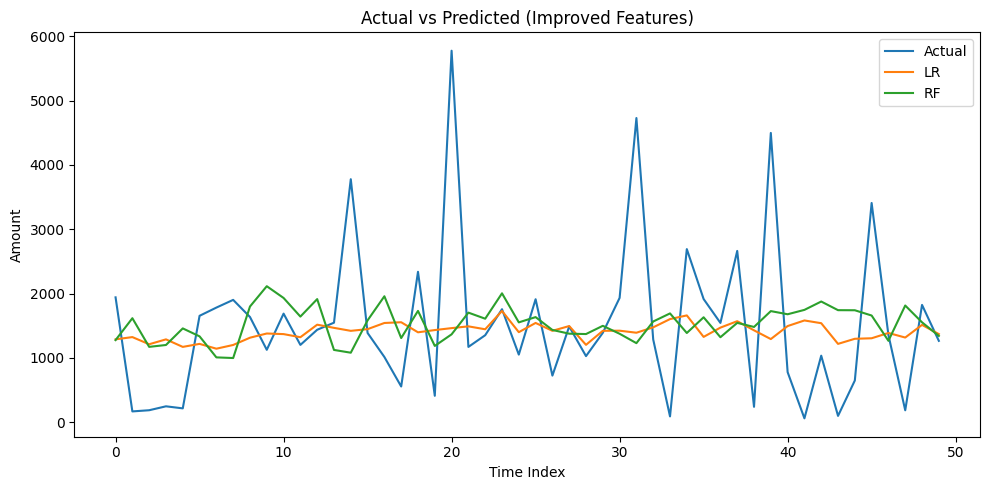

In [30]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(lr_pred[:50], label="LR")
plt.plot(rf_pred[:50], label="RF")
plt.legend()
plt.title("Actual vs Predicted (Improved Features)")
plt.xlabel("Time Index")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig("figures/prediction_plot.png", dpi=300, bbox_inches="tight")
plt.show()

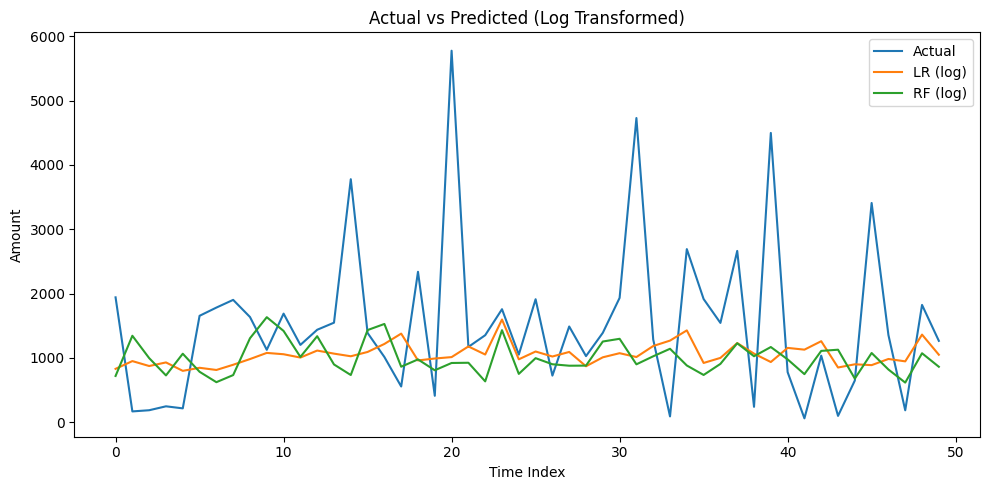

In [31]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(lr_pred_log[:50], label="LR (log)")
plt.plot(rf_pred_log[:50], label="RF (log)")
plt.legend()
plt.title("Actual vs Predicted (Log Transformed)")
plt.xlabel("Time Index")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig("figures/prediction_log_plot.png", dpi=300, bbox_inches="tight")
plt.show()

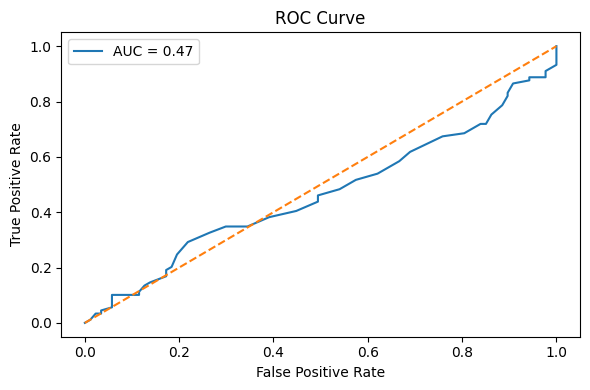

In [32]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("figures/roc.png", dpi=300, bbox_inches="tight")
plt.show()

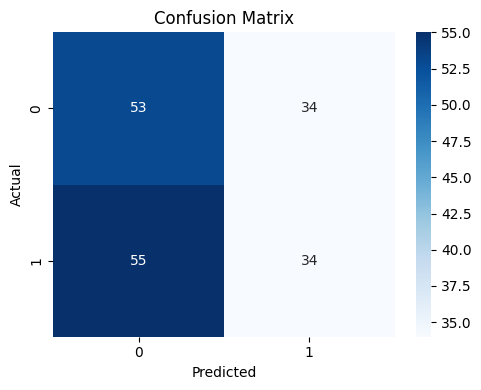

In [33]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("figures/confusion.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
print(os.listdir("figures"))

['category.png', 'elbow.png', 'histogram.png', 'pca.png', 'roc.png', 'confusion.png', 'prediction_plot.png', 'prediction_log_plot.png', 'timeseries.png']
